# 05: Risk diagnostics and scenario analysis

## Objective

This notebook demonstrates the interest-rate risk diagnostics in
`yieldcurve.risk`: dollar value of a basis point (DV01), the duration
conventions the package distinguishes, key-rate durations (KRD) and the
identity that reconciles their sum to the effective duration, a
principal-component decomposition of historical yield moves, the six
EU 2024/856 supervisory shock shapes applied as an illustrative Delta EVE
comparison, and a linearized delta value-at-risk / expected-shortfall proxy.

The instrument is a single 10-year US Treasury bond. Everything here is
educational: this is not a production risk system, not a regulatory
disclosure or outlier test, and no capital number is computed anywhere.

## Data

**Snapshot date:** 24 July 2026. All market data come from the committed
snapshot in `data/snapshots/2026-07-24/`.

**Test instrument:** 10-year US Treasury bond with the following
characteristics:
- Issue date: 24 July 2026
- Maturity date: 24 July 2036
- Coupon: 4.0% per annum
- Frequency: Semi-annual
- Day count: ACT/ACT ICMA
- Calendar: US Government Bond (SIFMA holidays)
- Business day convention: Following
- Notional: USD 1,000,000

The bond is a synthetic instrument constructed to fixed specifications for
reproducibility. The USD OIS curve (snapshot: `usd_ois_swaps.csv`) is used
for discounting, and the 3M SOFR forecast curve (`usd_forecast_basis.csv`)
for projecting floating-rate coupons — this bond has no floating leg, but
the curve set is the same dual-curve construction the rest of the repository
uses. Both curves are built with the canonical `usd_curveset` builder
(log-linear discount-factor bootstrap, exact sequential quote repricing on
the snapshot quotes).

**History:** the daily US Treasury CMT par-yield history
(`fred_treasury_cmt_history`) supplies the PCA factor calibration and the
historical P&L proxy. It is a CMT-implied history proxy, not an observed
funding-rate history.

## Theory

### DV01

**Dollar Value of a Basis Point (DV01)** is the package convention from
`yieldcurve.risk.sensitivities.dv01`:

> DV01 is `base - up` — the price falls when rates rise, so the number is
> positive for a long position. It is a positive loss, not a signed price
> change.

That is, for a 1 bp parallel rise in all zero rates, DV01 is the resulting
loss per 100 face. The printed unit is **USD per 100 face per 1 bp**.

### Duration conventions

The package distinguishes three conventions, and the names matter:

- **Effective duration** — central difference of price under a parallel
  1 bp zero-rate shift, normalized by the dirty price. This is the number
  the KRD sum must reconcile to.
- **Fisher-Weil duration** — the spot-curve-weighted mean time to cash
  flow: each cash flow is weighted by the discount factor *from the curve*,
  not from the yield. This is the correct name for curve-weighted mean time
  (formerly mislabelled Macaulay in some texts).
- **Macaulay duration** — the classical YTM-weighted mean time to cash
  flow: the same weighting scheme, but each flow is discounted at the
  instrument's own yield to maturity.

On a sloped curve the two differ; on a flat curve they coincide.

### Key-rate durations (KRD)

Following Ho (1992), the **key-rate duration** for key $k$ measures
sensitivity to a unit shock at tenor $k$ alone:

$$\text{KRD}_k = -\frac{1}{P}\,\frac{\Delta P}{\Delta y_k}$$

where the shock is a triangular "hat": full size at the key, linear to zero
at the neighbouring keys, flat outside the first and last keys. Each KRD is
computed by central finite difference with a 1 bp bump.

**Units:** the package quotes KRD in **price-bp per yield-bp** — a 1 bp
rise in the key rate moves the dirty price by that many price basis points
(1 price bp = 1e-4 of price), numerically equal to years of duration and
**not** multiplied by 100.

### The KRD sum identity

Because the hats form a partition of unity — at every tenor the hats sum to
a constant 1 bp shift — the sum of the key-rate durations equals the
parallel-shift duration, up to the $O(\text{bump}^2)$ truncation error of
the central finite differences. The identity is therefore a *completeness
check* on the hat basis: it is not exact to machine precision, and the
measured residual is part of the result, not something to round away.

## Methodology

### Bump size and central finite difference

KRDs and effective duration are computed by central finite difference with
a default bump of 1 bp (1e-4) applied symmetrically (±1 bp):

$$\text{Sensitivity} \approx \frac{P(y + \Delta y) - P(y - \Delta y)}{2 \Delta y}$$

A central difference is used rather than a one-sided one because the
one-sided error is $O(\text{bump})$ and, for a bond with any convexity at
all, biases duration systematically. The 1 bp bump keeps the truncation
error at $O(10^{-8})$ while staying well above the floating-point noise
floor.

### Shock application

Each scenario (key-rate hat or EU shock) is applied to the discount curve
and every forecast curve in the curve set, so the basis structure between
them is preserved and the shock measures a pure rate move rather than a
rate-plus-basis move.

## Regulatory context

The six shock shapes used below come from **Commission Delegated Regulation
(EU) 2024/856** of 1 December 2023 (the IRRBB RTS under CRD Article 98(5a);
OJ L, 24.4.2024, in force 14 May 2024). In the current EU framework:

1. **CRD Article 84** requires competent authorities to ensure institutions
   implement internal systems or a standardised methodology for interest
   rate risk arising from non-trading book activities (IRRBB), covering
   both economic value of equity (EVE) and net interest income (NII).
2. **CRD Article 98(5)** makes IRRBB part of the supervisory review
   (SREP), and Article 98(5a) mandates the EBA RTS on the six EVE
   scenarios, the two NII scenarios per currency, and the common modelling
   and parametric assumptions. That RTS is DR 2024/856.
3. **DR 2024/856** specifies the six supervisory shock scenarios (parallel
   up/down, short-rate up/down, steepener, flattener; Article 1), the
   $e^{-t/4}$ short-rate parameterisation and rotation weights (Article 2),
   the Article 3(7) maturity-dependent post-shock floor, and the "large
   decline" definition (Article 5). Its Annex Part A lists per-currency
   shock sizes; the USD row is 200 / 300 / 150 bp (parallel / short / long).
4. **CRR Article 448** ("Disclosure of exposures to interest rate risk on
   positions not held in the trading book"), as amended by CRR2 and in
   force since 28 June 2021, requires institutions to disclose the changes
   in EVE under the six supervisory shock scenarios and the changes in NII
   under the two NII scenarios of CRD Article 98(5), plus key modelling and
   parametric assumptions. The original 2013 wording ("variation in
   earnings, economic value or other relevant measure... broken down by
   currency") is historical and is not quoted here as current.
5. **EBA/GL/2018/02** (Guidelines on the management of interest rate risk
   arising from non-trading book activities, applicable from 30 June 2019)
   reflected the BCBS-specified supervisory shock scenarios; DR 2024/856
   builds on that specification and methodology, and the six-scenario
   parameters are now binding through DR 2024/856.

What this notebook does with them is deliberately bounded: the six USD
shocks are applied to a single bond book as an **illustrative Delta EVE
comparison** — a revaluation of the book on the shocked curve set. That is
not an institution-wide supervisory outlier test (no balance sheet, no EVE
aggregation, no 15%-of-Tier-1 threshold), not IRRBB compliance, not a
disclosure, and not a capital calculation. The numbers are educational
exhibits.

## Results

In [1]:
from __future__ import annotations

from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from yieldcurve.calendars import USGovernmentBondCalendar
from yieldcurve.conventions import BusinessDayConvention, DayCount
from yieldcurve.curves.build import usd_curveset
from yieldcurve.curves.pricing import price
from yieldcurve.instruments import FixedCouponBond
from yieldcurve.market.snapshot import Snapshot
from yieldcurve.risk.keyrate import USD_KEY_RATES, krd
from yieldcurve.risk.pca import daily_changes, fit_pca, pca_durations, pca_exposure
from yieldcurve.risk.portfolio import (
    Portfolio,
    Position,
    bucket_exposure,
    delta_eve,
    historical_pnl,
    present_value,
    var_es,
)
from yieldcurve.risk.scenarios import eu_scenarios, shift_curveset
from yieldcurve.risk.sensitivities import (
    dv01,
    effective_duration,
    fisher_weil_duration,
    instrument_scale,
    macaulay_duration,
)

In [2]:
# Set up snapshot, curves, and the test bond
ASOF = date(2026, 7, 24)
snapshot = Snapshot(date=ASOF)

# Discount curve (OIS) and 3M SOFR forecast curve, canonical log-linear build
curves = usd_curveset(snapshot, ASOF)

bond = FixedCouponBond(
    issue=ASOF,
    maturity=date(2036, 7, 24),
    coupon=0.04,
    frequency=2,
    day_count=DayCount.ACT_ACT_ICMA,
    calendar=USGovernmentBondCalendar(),
    bdc=BusinessDayConvention.FOLLOWING,
)

print("Test bond:")
print(f"  Maturity: {bond.maturity}")
print(f"  Coupon:   {bond.coupon * 100:.2f}% p.a., semi-annual")
print("  Face:     USD 100 per unit (price quotes per 100 face)")

Test bond:
  Maturity: 2036-07-24
  Coupon:   4.00% p.a., semi-annual
  Face:     USD 100 per unit (price quotes per 100 face)


In [3]:
# Valuation and the duration conventions
price_result = price(bond, curves, ASOF)
dirty_price = price_result.dirty

eff_dur = effective_duration(bond, curves, ASOF)
fw_dur = fisher_weil_duration(bond, curves, ASOF)
mac_dur = macaulay_duration(bond, curves, ASOF)
dv01_per_100 = dv01(bond, curves, ASOF)

print(f"Bond valuation at {ASOF} (USD per 100 face):")
print(f"  Dirty price: {dirty_price:,.6f} USD")
print(f"  Accrued:     {price_result.accrued:,.6f} USD")
print(f"  Clean price: {price_result.clean:,.6f} USD")
print()
print("Duration conventions (years):")
print(f"  Effective duration (parallel 1 bp zero shift, central difference): {eff_dur:.6f}")
print(f"  Fisher-Weil duration (spot-curve-weighted mean time):              {fw_dur:.6f}")
print(f"  Macaulay duration (YTM-weighted mean time):                       {mac_dur:.6f}")
print()
print(f"DV01 (positive loss per 1 bp rise, USD per 100 face): {dv01_per_100:.6f}")

Bond valuation at 2026-07-24 (USD per 100 face):
  Dirty price: 94.699733 USD
  Accrued:     0.000000 USD
  Clean price: 94.699733 USD

Duration conventions (years):
  Effective duration (parallel 1 bp zero shift, central difference): 8.277510
  Fisher-Weil duration (spot-curve-weighted mean time):              8.277509
  Macaulay duration (YTM-weighted mean time):                       8.283582

DV01 (positive loss per 1 bp rise, USD per 100 face): 0.078351


In [4]:
# Key-rate durations on the USD key-rate grid
krd_results = krd(bond, curves, ASOF, USD_KEY_RATES)

krd_df = pd.DataFrame(
    {
        "Key rate (years)": list(krd_results.keys()),
        "KRD (price-bp per yield-bp)": list(krd_results.values()),
    }
)

print("### Result: Key-rate durations (USD curve)")
print("Units: a 1 bp rise in the key rate moves the dirty price by that many")
print("price basis points (1 price bp = 1e-4 of price); numerically equal to")
print("years of duration; not multiplied by 100.")
print()
print(krd_df.to_string(index=False, float_format=lambda v: f"{v:,.6f}"))
print()

### Result: Key-rate durations (USD curve)
Units: a 1 bp rise in the key rate moves the dirty price by that many
price basis points (1 price bp = 1e-4 of price); numerically equal to
years of duration; not multiplied by 100.

 Key rate (years)  KRD (price-bp per yield-bp)
         0.250000                     0.000000
         0.500000                     0.010341
         1.000000                     0.035199
         2.000000                     0.077346
         3.000000                     0.182240
         5.000000                     0.337009
         7.000000                     0.553276
        10.000000                     7.076535
        20.000000                     0.005564
        30.000000                     0.000000



In [5]:
# KRD sum vs effective duration: the identity reconciliation
krd_sum = sum(krd_results.values())
rec_error = abs(krd_sum - eff_dur)
rec_rel = rec_error / eff_dur
tolerance = 1e-5  # years; the printed precision threshold used throughout

print("### KRD sum vs. effective duration (identity reconciliation)")
print(f"  Sum of KRDs:        {krd_sum:12.8f} years (price-bp per yield-bp)")
print(f"  Effective duration: {eff_dur:12.8f} years")
print(f"  Absolute error:     {rec_error:12.3e} years")
print(f"  Relative error:     {rec_rel:12.3e}  ({rec_rel * 100:.6f} %)")
print(f"  Tolerance:          |error| < {tolerance:.0e} years")
print(f"  Within tolerance:   {rec_error < tolerance}")
print()
print("The residual is the O(bump^2) central-difference truncation error: the")
print("hats partition unity exactly, but each KRD is a finite-difference")
print("estimate, so the sum matches the parallel-shift duration only to that")
print("order.")

### KRD sum vs. effective duration (identity reconciliation)
  Sum of KRDs:          8.27750979 years (price-bp per yield-bp)
  Effective duration:   8.27750985 years
  Absolute error:        6.123e-08 years
  Relative error:        7.397e-09  (0.000001 %)
  Tolerance:          |error| < 1e-05 years
  Within tolerance:   True

The residual is the O(bump^2) central-difference truncation error: the
hats partition unity exactly, but each KRD is a finite-difference
estimate, so the sum matches the parallel-shift duration only to that
order.


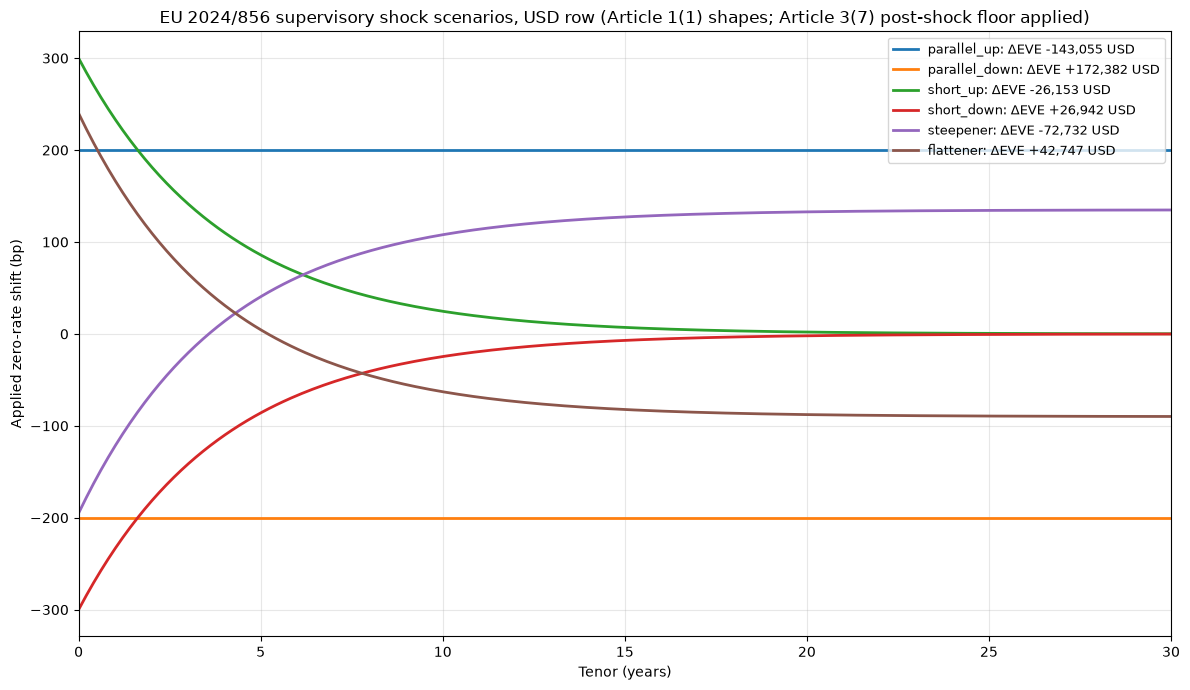

In [6]:
# The six EU 2024/856 supervisory shock scenarios (USD row), applied to the
# single-bond book as an illustrative Delta EVE comparison
scenarios = eu_scenarios("USD")

portfolio = Portfolio(
    positions=(
        Position(label="10y UST 4% (USD 1,000,000 face)", instrument=bond, notional=1_000_000.0),
    )
)
base_pv = present_value(portfolio, curves, ASOF)

times = np.linspace(0.01, 30, 300)
current_zeros = np.array([curves.discount.zero(t) for t in times])

fig, ax = plt.subplots(figsize=(12, 7))
delta_rows = []
for scenario in scenarios:
    shocked_zeros = np.array([shift_curveset(curves, scenario).discount.zero(t) for t in times])
    shift_bps = (shocked_zeros - current_zeros) * 1e4
    d_eve = delta_eve(portfolio, curves, ASOF, scenario)
    d_bp = d_eve / base_pv * 1e4
    delta_rows.append((scenario.name, d_eve, d_bp))
    ax.plot(times, shift_bps, label=f"{scenario.name}: \u0394EVE {d_eve:+,.0f} USD", linewidth=2)

ax.set_xlabel("Tenor (years)")
ax.set_ylabel("Applied zero-rate shift (bp)")
ax.set_title(
    "EU 2024/856 supervisory shock scenarios, USD row "
    "(Article 1(1) shapes; Article 3(7) post-shock floor applied)"
)
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 30])
plt.tight_layout()
plt.show()

In [7]:
# Scenario P&L summary table
scenario_df = pd.DataFrame(
    {
        "Scenario": [row[0] for row in delta_rows],
        "Illustrative \u0394EVE (USD, 1,000,000 face)": [row[1] for row in delta_rows],
        "\u0394EVE as share of base PV (bp of price)": [row[2] for row in delta_rows],
    }
)

print("### EU 2024/856 scenarios applied to the bond book")
print("Illustrative Delta EVE comparison: the book is revalued on each shocked")
print("curve set. Sign convention: negative \u0394EVE = value destroyed (a loss);")
print("positive = a gain. Base book value:")
print(f"  {base_pv:,.2f} USD (USD 1,000,000 face, dirty)")
print()
print(scenario_df.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))
print()
print("These are educational exhibits: not a supervisory outlier test, not a")
print("disclosure, and not a capital number.")

### EU 2024/856 scenarios applied to the bond book
Illustrative Delta EVE comparison: the book is revalued on each shocked
curve set. Sign convention: negative ΔEVE = value destroyed (a loss);
positive = a gain. Base book value:
  946,997.33 USD (USD 1,000,000 face, dirty)

     Scenario  Illustrative ΔEVE (USD, 1,000,000 face)  ΔEVE as share of base PV (bp of price)
  parallel_up                              -143,055.18                               -1,510.62
parallel_down                               172,381.83                                1,820.30
     short_up                               -26,152.61                                 -276.16
   short_down                                26,941.71                                  284.50
    steepener                               -72,731.68                                 -768.02
    flattener                                42,747.44                                  451.40

These are educational exhibits: not a supervisory outlier t

In [8]:
# PCA of the daily CMT yield-change history
hist = snapshot.load("fred_treasury_cmt_history")
changes, tenors = daily_changes(hist)
pca = fit_pca(changes, tenors, n_components=3)

date_min = str(hist["date"].min())[:10]
date_max = str(hist["date"].max())[:10]

print("### Principal-component decomposition of daily CMT yield changes")
print(
    f"History: {date_min} to {date_max} — {pca.n_observations} daily changes "
    f"on {len(tenors)} tenors ({', '.join(f'{t:g}y' for t in tenors)})"
)
print()
print("Component names are PC1/PC2/PC3 unless the loading's sign pattern")
print("matches the documented economic criterion (no sign change for level,")
print("one for slope, two for curvature); the diagnostic behind each name is")
print("printed as the loading shape.")
print()
for index, (name, shape, var_ratio, sd) in enumerate(
    zip(
        pca.component_names,
        pca.loading_shape,
        pca.explained_variance_ratio,
        pca.component_sd,
        strict=True,
    )
):
    print(
        f"  {name:9s} (PC{index + 1}): explained variance {var_ratio * 100:6.2f}% | "
        f"1-sigma move {sd * 1e4:7.2f} bp | loading shape: {shape}"
    )
print()

### Principal-component decomposition of daily CMT yield changes
History: 2021-07-26 to 2026-07-24 — 1248 daily changes on 11 tenors (0.0833y, 0.25y, 0.5y, 1y, 2y, 3y, 5y, 7y, 10y, 20y, 30y)

Component names are PC1/PC2/PC3 unless the loading's sign pattern
matches the documented economic criterion (no sign change for level,
one for slope, two for curvature); the diagnostic behind each name is
printed as the loading shape.

  level     (PC1): explained variance  73.19% | 1-sigma move   16.86 bp | loading shape: sign-consistent (no sign change)
  slope     (PC2): explained variance  10.39% | 1-sigma move    6.35 bp | loading shape: one sign change
  curvature (PC3): explained variance   9.50% | 1-sigma move    6.07 bp | loading shape: two sign changes



In [9]:
# PCA-derived risk measures: direction duration vs one-sigma exposure
pca_durs = pca_durations(bond, curves, ASOF, pca)
pca_expos = pca_exposure(bond, curves, ASOF, pca)

print("Direction-only duration along each component's unit-norm loading")
print("(years per 1.0 zero-rate shift along the direction; the component's")
print("empirical volatility is not involved):")
for name, value in pca_durs.items():
    print(f"  {name:9s}: {value:9.4f} years")
print()
print("One-standard-deviation exposure (fractional price change for a 1-sigma")
print("move along the component; empirical scale retained; dimensionless):")
for name, value in pca_expos.items():
    print(f"  {name:9s}: {value:+.6f}  ({value * 1e4:+.2f} bp of price)")
print()
print("Sign convention: positive = the position loses value when the zero")
print("curve moves +1 sigma along the component — the same positive-loss")
print("convention as DV01.")
print()
print("Consistency check, exposure[k] == duration[k] x component_sd[k]:")
for name, d, e, sd in zip(
    pca.component_names, pca_durs.values(), pca_expos.values(), pca.component_sd, strict=True
):
    print(f"  {name:9s}: {e:+.6f} vs {d * sd:+.6f}")

Direction-only duration along each component's unit-norm loading
(years per 1.0 zero-rate shift along the direction; the component's
empirical volatility is not involved):
  level    :    2.9603 years
  slope    :   -0.3516 years
  curvature:    1.8933 years

One-standard-deviation exposure (fractional price change for a 1-sigma
move along the component; empirical scale retained; dimensionless):
  level    : +0.004991  (+49.91 bp of price)
  slope    : -0.000223  (-2.23 bp of price)
  curvature: +0.001150  (+11.50 bp of price)

Sign convention: positive = the position loses value when the zero
curve moves +1 sigma along the component — the same positive-loss
convention as DV01.

Consistency check, exposure[k] == duration[k] x component_sd[k]:
  level    : +0.004991 vs +0.004991
  slope    : -0.000223 vs -0.000223
  curvature: +0.001150 vs +0.001150


In [10]:
# Historical VaR / expected shortfall: a linearized delta proxy
pnl = historical_pnl(portfolio, curves, ASOF, changes, tenors, USD_KEY_RATES)
var99, es99 = var_es(pnl, confidence=0.99)

print("### Historical VaR and expected shortfall (linearized delta proxy)")
print("Construction: the book's key-rate bucket exposures at the valuation")
print("date are contracted with the daily CMT yield changes above — a")
print("CMT-implied history proxy, not an observed funding-rate history.")
print("First-order (delta) only: no full revaluation, no FRTB or other")
print("regulatory measure. Treat the numbers as a volatility proxy.")
print()
print(f"  Window: {date_min} to {date_max} ({len(pnl)} daily changes)")
print(f"  Book:   10y UST 4%, USD 1,000,000 face, base PV {base_pv:,.2f} USD")
print(f"  VaR 99%: {var99:,.2f} USD  ({var99 / base_pv * 100:.3f}% of base PV)")
print(f"  ES  99%: {es99:,.2f} USD  ({es99 / base_pv * 100:.3f}% of base PV)")
print("  Convention: losses are the negated P&L observations; both numbers")
print("  are non-negative loss magnitudes, and ES >= VaR by construction.")

### Historical VaR and expected shortfall (linearized delta proxy)
Construction: the book's key-rate bucket exposures at the valuation
date are contracted with the daily CMT yield changes above — a
CMT-implied history proxy, not an observed funding-rate history.
First-order (delta) only: no full revaluation, no FRTB or other
regulatory measure. Treat the numbers as a volatility proxy.

  Window: 2021-07-26 to 2026-07-24 (1248 daily changes)
  Book:   10y UST 4%, USD 1,000,000 face, base PV 946,997.33 USD
  VaR 99%: 11,395.89 USD  (1.203% of base PV)
  ES  99%: 13,643.70 USD  (1.441% of base PV)
  Convention: losses are the negated P&L observations; both numbers
  are non-negative loss magnitudes, and ES >= VaR by construction.


In [11]:
# Independently pinned asymmetric loss example (hand-computed)
asym_pnl = np.array([5.0] * 85 + [-10.0] * 12 + [-50.0] * 3)
asym_var, asym_es = var_es(asym_pnl, confidence=0.90)

print("### Independently pinned asymmetric loss example")
print("100 P&L observations (gains positive):")
print("  85 x +5.0   (small gains)")
print("  12 x -10.0  (moderate losses)")
print("   3 x -50.0  (large losses)")
print()
print("Hand computation at 90% confidence (losses = negated P&L):")
print("  Loss distribution: 85 x -5.0, 12 x +10.0, 3 x +50.0")
print("  VaR = 90th percentile of losses = 10.0")
print("  Tail = losses >= 10.0 = 15 observations (12 x 10.0 + 3 x 50.0)")
print("  ES  = mean of the tail = (120.0 + 150.0) / 15 = 18.0")
print()
print(
    f"  var_es returns: VaR = {asym_var:.1f}, ES = {asym_es:.1f}  "
    f"(ES >= VaR: {asym_es >= asym_var})"
)
print()
print("The asymmetry is the point: the three large losses sit beyond VaR,")
print("and only expected shortfall sees them — the loss-positive convention")
print("keeps both numbers non-negative.")

### Independently pinned asymmetric loss example
100 P&L observations (gains positive):
  85 x +5.0   (small gains)
  12 x -10.0  (moderate losses)
   3 x -50.0  (large losses)

Hand computation at 90% confidence (losses = negated P&L):
  Loss distribution: 85 x -5.0, 12 x +10.0, 3 x +50.0
  VaR = 90th percentile of losses = 10.0
  Tail = losses >= 10.0 = 15 observations (12 x 10.0 + 3 x 50.0)
  ES  = mean of the tail = (120.0 + 150.0) / 15 = 18.0

  var_es returns: VaR = 10.0, ES = 18.0  (ES >= VaR: True)

The asymmetry is the point: the three large losses sit beyond VaR,
and only expected shortfall sees them — the loss-positive convention
keeps both numbers non-negative.


In [12]:
# Portfolio face/notional scaling (per-100-face unit prices)
units = 500_000.0 / instrument_scale(bond)
scaled_portfolio = Portfolio(
    positions=(
        Position(label="10y UST 4% (USD 500,000 face)", instrument=bond, notional=500_000.0),
    )
)
scaled_pv = present_value(scaled_portfolio, curves, ASOF)
scaled_dv01 = units * dv01_per_100
k10 = krd_results[10.0]
hand_k10_loss = units * k10 * dirty_price * 1e-4
bucket10_per_bp = bucket_exposure(scaled_portfolio, curves, ASOF, USD_KEY_RATES)[10.0] * 1e-4
scaled_pnl = historical_pnl(scaled_portfolio, curves, ASOF, changes, tenors, USD_KEY_RATES)
scaled_var, scaled_es = var_es(scaled_pnl, confidence=0.99)

print("### Portfolio face/notional scaling (per-100-face unit prices)")
print("price() quotes per 100 face; a position of N face is N / instrument_scale")
print("= N / 100 units of the unit price. Take the same bond with N = 500,000")
print("face (5,000 units):")
print()
print(f"  Units: {units:,.0f} = 500,000 / 100")
print(f"  Hand:     position value = 5,000 x {dirty_price:,.6f} = {units * dirty_price:,.2f} USD")
print(f"  Library:  present_value = {scaled_pv:,.2f} USD")
print(f"  Hand:     DV01 = 5,000 x {dv01_per_100:.6f} = {scaled_dv01:,.2f} USD per 1 bp")
print(f"  Hand:     10y-key loss per 1 bp = 5,000 x {k10:.6f} x {dirty_price:.6f} x 1e-4")
print(f"           = {hand_k10_loss:,.2f} USD (loss magnitude)")
print(f"  Library:  bucket_exposure(10y) per 1 bp = {bucket10_per_bp:,.2f} USD")
print("           (signed change in book value; negative = loss; bucket_exposure")
print("           is per 1.0 (decimal) rate; 1 bp = 1e-4 of that)")
print(f"  VaR 99% / ES 99%: {scaled_var:,.2f} / {scaled_es:,.2f} USD")
print(f"  (1,000,000-face book: {var99:,.2f} / {es99:,.2f} USD — risk scales linearly")
print("   with face, so half the face means half the risk)")

### Portfolio face/notional scaling (per-100-face unit prices)
price() quotes per 100 face; a position of N face is N / instrument_scale
= N / 100 units of the unit price. Take the same bond with N = 500,000
face (5,000 units):

  Units: 5,000 = 500,000 / 100
  Hand:     position value = 5,000 x 94.699733 = 473,498.67 USD
  Library:  present_value = 473,498.67 USD
  Hand:     DV01 = 5,000 x 0.078351 = 391.76 USD per 1 bp
  Hand:     10y-key loss per 1 bp = 5,000 x 7.076535 x 94.699733 x 1e-4
           = 335.07 USD (loss magnitude)
  Library:  bucket_exposure(10y) per 1 bp = -335.07 USD
           (signed change in book value; negative = loss; bucket_exposure
           is per 1.0 (decimal) rate; 1 bp = 1e-4 of that)
  VaR 99% / ES 99%: 5,697.94 / 6,821.85 USD
  (1,000,000-face book: 11,395.89 / 13,643.70 USD — risk scales linearly
   with face, so half the face means half the risk)


## Interpretation

### The KRD-to-effective-duration identity

The two quantities reaching the same answer is worth pausing on, because
they are not the same calculation performed twice. Effective duration comes
from a single parallel shift of the entire curve and one pair of repricings.
The key-rate durations come from ten separate repricings, each perturbing
one pillar through a triangular hat function that decays to zero at its
neighbours. Nothing in the code forces the ten to reconcile to the one.

They reconcile because the hat functions form a partition of unity: added
together, they sum to a constant one basis point at every maturity across
the covered span, with the flat extrapolation outside the first and last
pillars supplying the tails. Summing the key-rate bumps therefore rebuilds
precisely the parallel shift that effective duration applies in a single
step.

The measured residual here is about 6e-8 years with a 1 bp bump. That is
the $O(\text{bump}^2)$ truncation error of the central differences, not an
exactness miracle: the identity is a completeness check on the hat basis.
No maturity range is double-counted or left uncovered, and the bond's price
response is close to linear over a one basis point move, so first-order
additivity survives to that precision. A residual at the basis-point level
would point to a gap in the basis or a mismatch in bump conventions.

### What the key-rate durations show

The KRD table tells us where on the yield curve the bond's risk is
concentrated. For a 10-year bullet bond:

- **Peak KRD at the 10-year key** (about 7.1 of the 8.28 years of effective
  duration): the redemption payment is by far the largest cash flow, and it
  lands exactly on that key.
- **Small positive KRDs at the intermediate keys** (0.5y to 7y): these
  carry the coupons. Their magnitudes track the coupon cash-flow sizes.
- **Zero KRDs at the 0.25y and 30y keys**, and essentially zero at 20y:
  the hat at 0.25y vanishes at the first coupon date (0.5y), and the hats
  at 20y/30y only move rates beyond the bond's 10-year maturity, which
  affects none of its cash flows. The 20y hat still catches a small
  weight through hat-grid interpolation at the 10y boundary.

### The EU 2024/856 scenario ranking

With the sign convention stated (negative $\Delta$EVE = loss), the six
scenarios rank as follows for this long-duration bond:

1. **Parallel up** — the largest loss: a uniform rate rise reduces the
   present value of every cash flow.
2. **Steepener** — the second-largest loss: short rates fall (a small gain
   on the near coupons) while long rates rise (a large loss on the
   redemption payment).
3. **Short up** — an intermediate loss: the exponentially decaying shock is
   large at the short end but milder where this bond's value sits.
4. **Flattener** — a gain: the mirror of the steepener, long rates fall.
5. **Short down** — a smaller gain: short rates fall, which helps the early
   coupons but barely touches the 10-year redemption.
6. **Parallel down** — the largest gain: a uniform rate fall.

This ranking is specific to a long-duration bullet near the positive-
convexity region; callable, putable, or floating-rate books would show
different profiles.

### The PCA factors

The three components explain most of the historical variance (about 73%,
10% and 10%), and on this history each loading's sign pattern matches the
economic criterion for its position — no sign change, one sign change, two
sign changes — so the API names them level, slope and curvature rather than
the neutral PC1/PC2/PC3. The loading-shape diagnostics are printed so the
naming decision is transparent. Note the unit-norm convention: a 1.0 shift
"along the direction" is a 1.0 move of the *unit-norm loading*, which for
level is roughly a 0.36 decimal (~3600 bp) parallel move, so the
direction duration (years
per 1.0 shift) is not the parallel duration. The economically meaningful
number is the one-sigma exposure, which multiplies the direction duration
by the component's empirical standard deviation and so keeps the scale of
the history.

### VaR and expected shortfall

The VaR/ES pair is a *linearized delta proxy* on a CMT-implied history: the
bond's bucket exposures at the valuation date are contracted with daily
yield changes. It is not a full revaluation, not a regulatory measure, and
not even an observed funding-rate history — it is a volatility proxy, and
the honest reading is "this is how big a one-day move the *proxy* thinks
the book could take", not a prediction about tomorrow. The conventions are
those of `yieldcurve.risk.portfolio.var_es`: losses are the negated P&L
observations, both numbers are non-negative loss magnitudes, and ES — the
mean of the tail beyond VaR — is never the smaller of the two. The pinned
asymmetric example makes the tail behaviour explicit: three large losses
hide beyond the 90th percentile, and only ES sees them.

## Limitations

1. **Finite-bump linearity:** KRDs and effective duration are first-order
   measures computed with a 1 bp finite bump; convexity is not reported.
   The scenario exhibits revalue the book under shocks up to 200 bp, so
   their $\Delta$EVE is a full revaluation and includes convexity — which
   is exactly why the scenario losses are not simply duration times shock.
2. **Fixed basis structure:** the methodology assumes the snapshot's
   forecast basis at all tenors; basis changes over time are not modelled.
   The numbers are specific to the 24 July 2026 snapshot.
3. **No credit or liquidity risk:** the bond is discounted at OIS as if
   risk-free. Treasury bonds carry a liquidity premium in reality; the
   risk diagnostics measure interest-rate risk only.
4. **PCA calibration window:** the components are fitted to one 5-year
   daily history (2021-2026) and are not regime-stable or guaranteed to
   generalise; the naming depends on loading shapes that can change with
   the window.
5. **Illustrative scenarios:** the six shocks use the EU 2024/856 Annex
   Part A USD sizes and Article 1(1) shapes with the Article 3(7) floor.
   They are illustrative educational exhibits — neither a baseline nor a
   ceiling on tail risk, not a supervisory outlier test, and not
   regulatory-applicable to anything this repository produces.
6. **Linearized risk proxy:** the VaR/ES numbers are a first-order delta
   proxy on a CMT-implied history, not a full revaluation and not an
   observed funding-rate history; treat them as a volatility proxy only.
7. **No execution costs:** the $\Delta$EVE exhibits assume the book can be
   liquidated at model prices with no bid-ask spread or market impact.

## Summary

This notebook demonstrates the risk diagnostics in `yieldcurve.risk` on one
10-year US Treasury bond:

1. **DV01** as a positive loss per 1 bp rise, in USD per 100 face.
2. **Duration conventions** named correctly: effective (parallel-shift
   central difference), Fisher-Weil (spot-curve-weighted), and Macaulay
   (YTM-weighted).
3. **Key-rate durations** in price-bp per yield-bp, whose sum reconciles
   to the effective duration to within the $O(\text{bump}^2)$ truncation
   error of the central differences — measured at about 6e-8 years.
4. **Principal components** of the CMT yield-change history, with
   economically named level/slope/curvature components only where the
   loading-shape criteria pass, direction durations and one-sigma exposures
   kept as separate, explicitly unit-ed quantities.
5. **The six EU 2024/856 supervisory shock shapes** applied as an
   illustrative Delta EVE comparison, with the regulatory boundary stated.
6. **A linearized delta VaR/ES proxy** on a CMT-implied history, with the
   loss-positive convention, plus an independently pinned asymmetric-loss
   example and a face/notional scaling example.

Everything here is an educational demonstration on a frozen snapshot: the
toolkit is not a production risk platform, nothing here is a regulatory
disclosure or an outlier test, and no capital number is computed.